# 4. User Generation


## 1. Setup and Current Generator Inputs

The day-cycle layer uses three inputs in this walkthrough:

- the hourly offered-load curve from CSV,
- the quarter-hour bin resolution used by the simulator, and
- the preset catalogs used to build each synthetic session.

Each generated session carries one distance preset, one total-data preset, one start bin, and one nominal duration. The scheduler-facing rate is then obtained by spreading the total session payload uniformly across the occupied bins.

The preset values shown below are read directly from the active configuration. This keeps the notebook aligned with later edits to the session catalogs.


In [1]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

repo_root = next(
    (candidate for candidate in (Path.cwd(), Path.cwd().parent) if (candidate / "src").exists()),
    Path.cwd(),
)
DOC_IMG_DIR = repo_root / "img"
DOC_IMG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str((repo_root / "src").resolve()))

from configs.day_cycle import DEFAULT_SYNTHETIC_SESSION_GENERATION_CONFIG
from helpers.DayCycleSimulationHelpers import (
    BITS_PER_GB,
    build_day_cycle_discussion_artifacts,
    export_doc_figure,
    plot_hourly_offered_load,
    plot_session_blocks,
    plot_target_bins,
    plot_target_rebuild_and_activity,
    style_catalog_table,
    style_mix_table,
    style_scheduler_rows_table,
    style_session_overview_table,
    style_summary_table,
    style_target_preview_table,
)


In [2]:
load_curve_csv = repo_root / "data" / "half_load_curve.csv"
config = DEFAULT_SYNTHETIC_SESSION_GENERATION_CONFIG

artifacts = build_day_cycle_discussion_artifacts(load_curve_csv, config)

hourly_load_table = artifacts["hourly_load_table"]
target_load_table = artifacts["target_load_table"]
session_table = artifacts["session_table"]
lane_table = artifacts["lane_table"]
scheduler_day_user_table = artifacts["scheduler_day_user_table"]
catalog_table = artifacts["catalog_table"]
realized_mix_table = artifacts["realized_mix_table"]
bin_validation_table = artifacts["bin_validation_table"]
generator_summary = artifacts["generator_summary"]
target_preview = artifacts["target_preview"]
population_summary = artifacts["population_summary"]
session_sample_table = artifacts["session_sample_table"]
example_session_view = artifacts["example_session_view"]
example_scheduler_rows = artifacts["example_scheduler_rows"]
validation_summary = artifacts["validation_summary"]
smallest_total_data_gb = artifacts["smallest_total_data_gb"]


In [3]:
display(style_summary_table(generator_summary, caption="Generator overview"))
display(style_catalog_table(catalog_table, caption="Current preset catalog"))


Load curve file,Hourly samples,Quarter-hour bins,Synthetic sessions,Scheduler rows,Max concurrent session lanes
half_load_curve.csv,24,96,304,536,11


Preset family,Preset value,Sampling weight,Interpretation
Distance,50 m,0.080,Link distance passed to the later radio layers
Distance,125 m,0.220,Link distance passed to the later radio layers
Distance,200 m,0.340,Link distance passed to the later radio layers
Distance,300 m,0.240,Link distance passed to the later radio layers
Distance,500 m,0.120,Link distance passed to the later radio layers
Total session data,2.00 GB,0.140,Whole-session payload before per-bin expansion
Total session data,8.00 GB,0.290,Whole-session payload before per-bin expansion
Total session data,16.00 GB,0.420,Whole-session payload before per-bin expansion
Total session data,32.00 GB,0.150,Whole-session payload before per-bin expansion
Nominal session duration,1 bin (15 min),0.500,Nominal occupancy before the per-bin user table is built


## 2. From the 24-Hour Curve to 96 Quarter-Hour Bins

The hourly CSV is the macro traffic description. The day-cycle module does not interpolate between those points. Instead, each hourly offered-load value is copied into four consecutive quarter-hour bins, and each bin receives one quarter of the hourly traffic volume.

The first figure keeps the original GB/h units. The second figure switches to the per-bin quantity that the generator must satisfy.


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_cycle_macro_load_curve.png


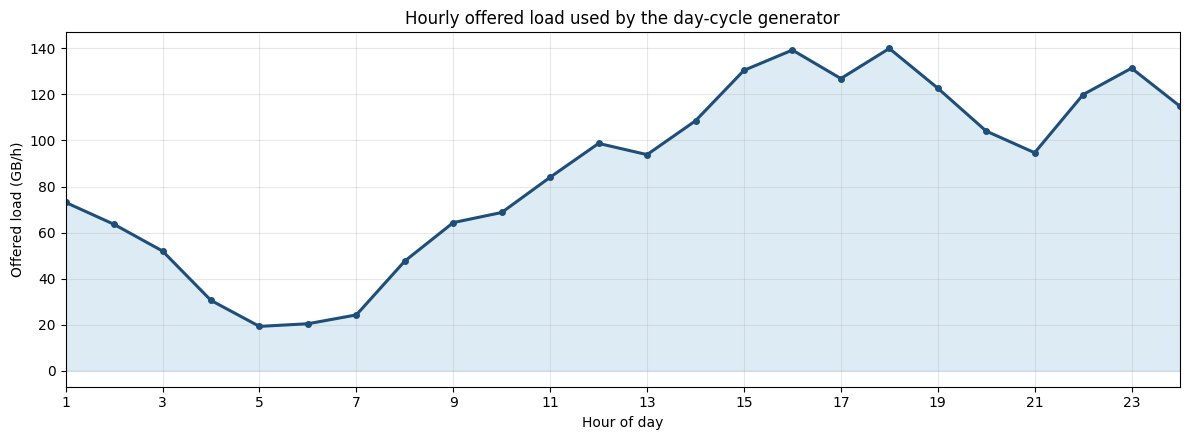

In [4]:
fig, ax = plot_hourly_offered_load(hourly_load_table)
export_doc_figure(fig, "day_cycle_macro_load_curve.png", DOC_IMG_DIR)
plt.show()


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_cycle_15_minute_target_bins.png


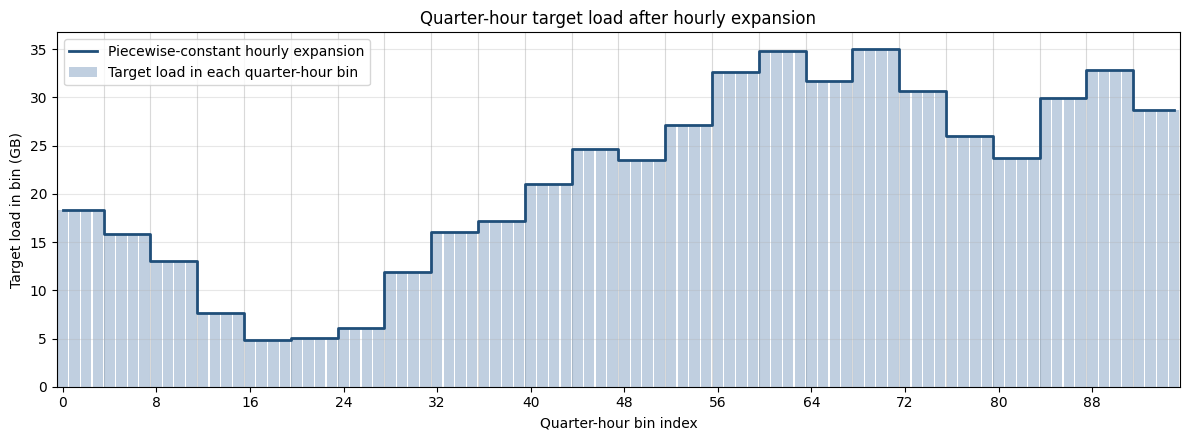

Bin index,Hour,Target load in bin (GB)
0,1,18.274
1,1,18.274
2,1,18.274
3,1,18.274
4,2,15.888
5,2,15.888
6,2,15.888
7,2,15.888


In [5]:
fig, ax = plot_target_bins(
    target_load_table,
    bin_validation_table,
    day_bin_count=int(config.day_bin_count),
)
export_doc_figure(fig, "day_cycle_15_minute_target_bins.png", DOC_IMG_DIR)
plt.show()

display(
    style_target_preview_table(
        target_preview,
        caption="First eight quarter-hour bins after hourly expansion",
    )
)


## 3. Generate Synthetic Sessions That Track the Bin Targets

The generator now works against the remaining bin demand. Each sampled session contributes a uniform amount of traffic across its nominal duration, and the process repeats until every quarter-hour bin carries less residual traffic than the smallest total-data preset.

The summary tables below show the generated population, the realised preset mix, and a short sample of the resulting sessions. The block plot that follows is a demand-construction view rather than a scheduler result. Rectangle width shows duration, colour shows total session data, and the vertical stacking only makes overlapping sessions visible.


In [6]:
display(style_summary_table(population_summary, caption="Generated population summary"))
display(
    style_session_overview_table(
        session_sample_table.head(4),
        caption="Example generated sessions",
    )
)


Synthetic sessions,Mean active users per bin,Peak active users in one bin,Peak per-user required rate (Mbps),Target day traffic (TB),Max residual load in bin (GB)
304,5.58,11,142.22,2.073,1.955


Session ID,Distance (m),Total data (GB),Start time,Stop time,Duration (bins),Required rate (Mbps)
67,300,16.00,00:00,00:15,1,142.22
194,125,2.00,00:00,00:30,2,8.89
248,300,2.00,00:00,00:30,2,8.89
164,200,2.00,00:15,00:30,1,17.78


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_cycle_session_blocks.png


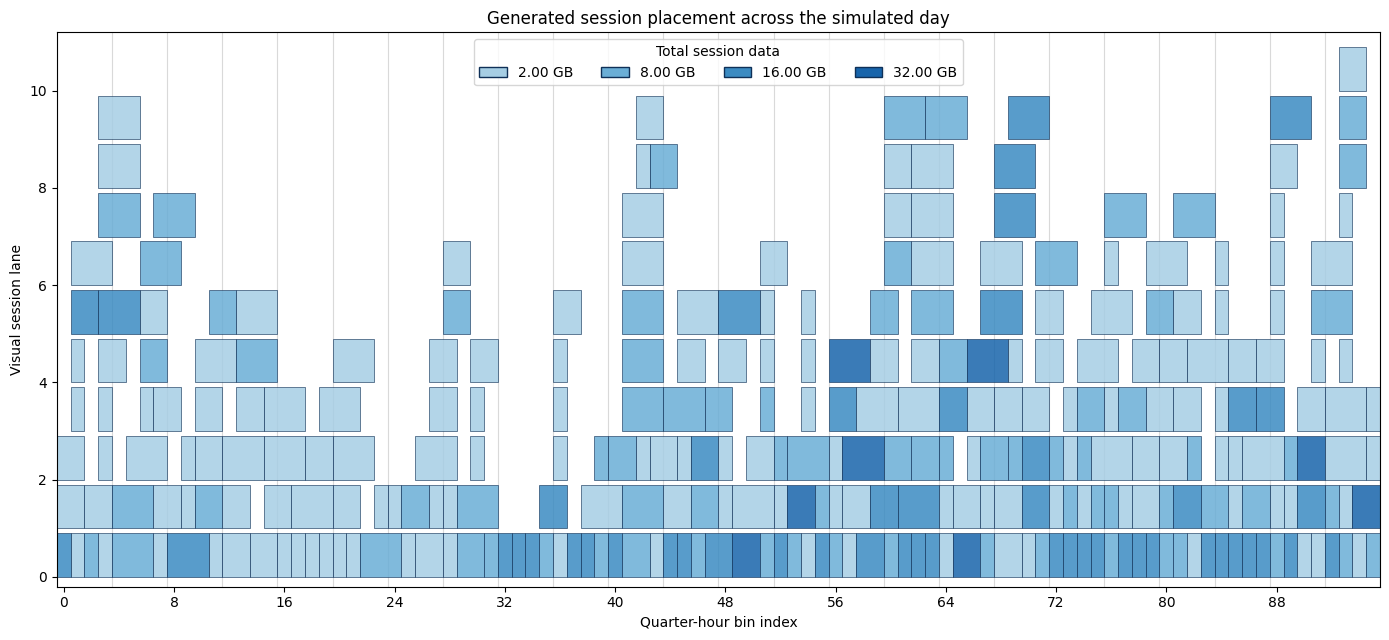

In [7]:
fig, ax = plot_session_blocks(lane_table, day_bin_count=int(config.day_bin_count))
export_doc_figure(fig, "day_cycle_session_blocks.png", DOC_IMG_DIR)
plt.show()


## 4. Expand Sessions into the Scheduler-Facing User Table

The later day orchestration does not consume whole sessions directly. Instead, each session is expanded into one row per occupied quarter-hour bin, and every row keeps only the fields the scheduler needs: `user_id`, `distance_m`, and `required_rate_bps`.

The example below shows one generated three-bin session and the repeated scheduler rows that it contributes to the final day table.


In [8]:
display(
    style_session_overview_table(
        example_session_view,
        caption="One example generated session",
    )
)
display(
    style_scheduler_rows_table(
        example_scheduler_rows,
        caption="Scheduler rows produced by that session",
    )
)


Session ID,Distance (m),Total data (GB),Start time,Stop time,Duration (bins),Duration (min),Required rate (Mbps)
175,200,2.00,00:15,01:00,3,45,5.93


Bin index,User ID,Distance (m),Required rate (Mbps)
1,175,200,5.93
2,175,200,5.93
3,175,200,5.93


## 5. Validate the Rebuilt Bin Load and Bridge to the Scheduler

At this point the day-cycle layer is complete. One hourly load curve has been converted into 96 scheduler-ready user batches, and the generated sessions reproduce that target while leaving only a small residual in each bin by construction.

The validation below checks that the rebuilt bin traffic remains within the preset floor and shows the active user count seen by the later scheduler.


Target day traffic (TB),Generated day traffic (TB),Captured traffic share,Max residual load in bin (GB),Peak active users
2.073,2.02,0.976,1.955,11


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_cycle_target_vs_generated_bins.png


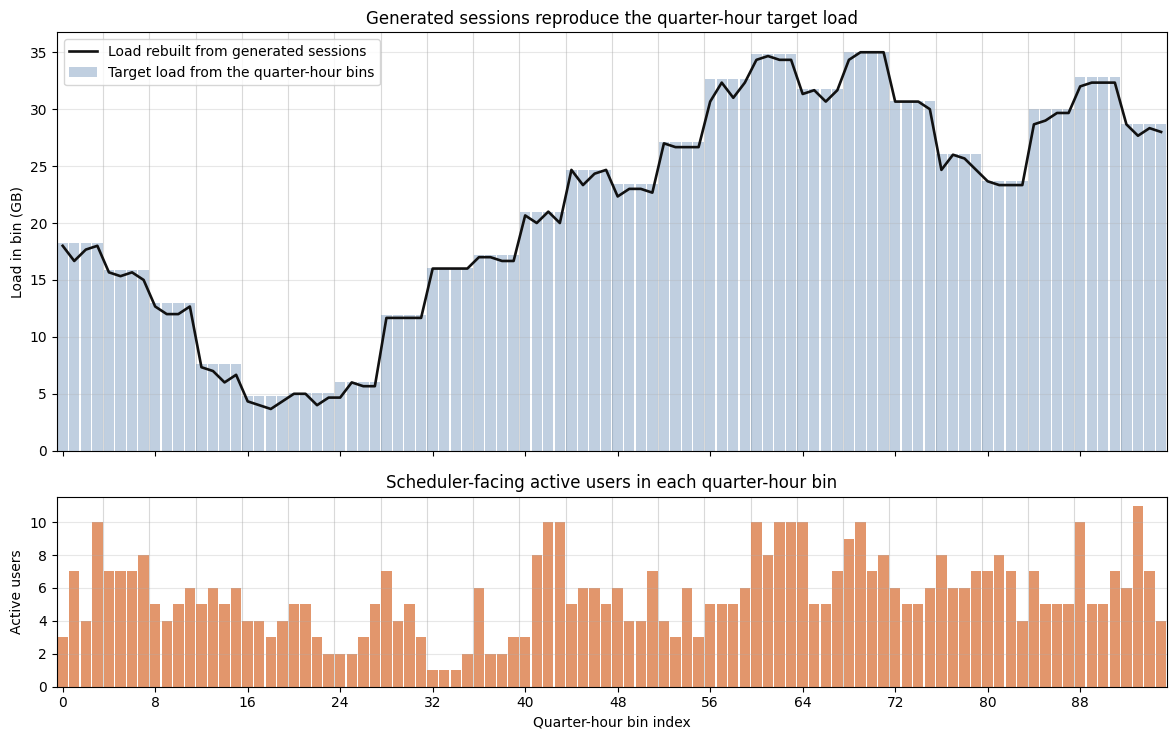

In [9]:
residual_bits = bin_validation_table["residual_load_gb_in_bin"].to_numpy(dtype=float) * BITS_PER_GB
assert np.all(residual_bits >= -1.0)
assert np.all(residual_bits < float(min(config.total_data_presets_bits)) + 1.0)

display(
    style_summary_table(
        validation_summary,
        caption="Validation summary",
    )
)

fig, axes = plot_target_rebuild_and_activity(
    bin_validation_table,
    day_bin_count=int(config.day_bin_count),
)
export_doc_figure(fig, "day_cycle_target_vs_generated_bins.png", DOC_IMG_DIR)
plt.show()


The next stage is therefore no longer demand generation. It is bin-by-bin radio scheduling: for each active quarter-hour bin, the later single-user and TDMA layers can take the users produced here and solve the PHY and joint resource-allocation problem.


In [14]:
from IPython.display import display

from helpers.DayCycleSimulationHelpers import style_scheduler_rows_table
from helpers.tdma_scheduling_helpers import build_user_requirements_table
from models import UserRequest

scheduler_day_user_table = (
    artifacts["scheduler_day_user_table"]
    .sort_values(["bin_index", "user_id"])
    .reset_index(drop=True)
)

FIRST_BIN_INDEX = 0
DISCUSSED_BIN_INDEX = 88  # this is the 63rd bin if counted from 1


def extract_bin_requests(
    scheduler_day_user_table,
    *,
    bin_index: int,
) -> tuple[tuple[UserRequest, ...], object, object]:
    user_table = (
        scheduler_day_user_table.loc[
            scheduler_day_user_table["bin_index"].eq(int(bin_index)),
            ["user_id", "distance_m", "required_rate_bps"],
        ]
        .sort_values("user_id")
        .reset_index(drop=True)
    )

    requests = tuple(
        UserRequest(
            user_id=int(row.user_id),
            distance_m=float(row.distance_m),
            required_rate_bps=float(row.required_rate_bps),
        )
        for row in user_table.itertuples(index=False)
    )

    display_table = (
        build_user_requirements_table(requests)
        .assign(**{"Required rate (Mbps)": lambda df: df["required_rate_bps"] / 1e6})
        .rename(
            columns={
                "user_id": "User ID",
                "distance_m": "Distance (m)",
            }
        )[["User ID", "Distance (m)", "Required rate (Mbps)"]]
    )

    return requests, user_table, display_table


def format_request_tuple(name: str, requests: tuple[UserRequest, ...]) -> str:
    lines = [
        (
            f"    UserRequest(user_id={request.user_id}, "
            f"distance_m={request.distance_m:.1f}, "
            f"required_rate_bps={request.required_rate_bps:.1f}),"
        )
        for request in requests
    ]
    return f"{name} = (\n" + "\n".join(lines) + "\n)"


first_bin_requests, first_bin_user_table, first_bin_display = extract_bin_requests(
    scheduler_day_user_table,
    bin_index=FIRST_BIN_INDEX,
)

bin_62_requests, bin_62_user_table, bin_62_display = extract_bin_requests(
    scheduler_day_user_table,
    bin_index=DISCUSSED_BIN_INDEX,
)

display(
    style_scheduler_rows_table(
        first_bin_display,
        caption=f"First bin (index {FIRST_BIN_INDEX})",
    )
)

display(
    style_scheduler_rows_table(
        bin_62_display,
        caption=f"Discussed bin (index {DISCUSSED_BIN_INDEX})",
    )
)

print(format_request_tuple("first_bin_requests", first_bin_requests))
print()
print(format_request_tuple("bin_62_requests", bin_62_requests))


User ID,Distance (m),Required rate (Mbps)
67,300,142.22
194,125,8.89
248,300,8.89


User ID,Distance (m),Required rate (Mbps)
1,300,47.41
11,200,71.11
36,300,17.78
98,125,71.11
137,200,8.89
188,300,8.89
212,300,17.78
216,300,5.93
232,300,17.78
282,300,17.78


first_bin_requests = (
    UserRequest(user_id=67, distance_m=300.0, required_rate_bps=142222222.2),
    UserRequest(user_id=194, distance_m=125.0, required_rate_bps=8888888.9),
    UserRequest(user_id=248, distance_m=300.0, required_rate_bps=8888888.9),
)

bin_62_requests = (
    UserRequest(user_id=1, distance_m=300.0, required_rate_bps=47407407.4),
    UserRequest(user_id=11, distance_m=200.0, required_rate_bps=71111111.1),
    UserRequest(user_id=36, distance_m=300.0, required_rate_bps=17777777.8),
    UserRequest(user_id=98, distance_m=125.0, required_rate_bps=71111111.1),
    UserRequest(user_id=137, distance_m=200.0, required_rate_bps=8888888.9),
    UserRequest(user_id=188, distance_m=300.0, required_rate_bps=8888888.9),
    UserRequest(user_id=212, distance_m=300.0, required_rate_bps=17777777.8),
    UserRequest(user_id=216, distance_m=300.0, required_rate_bps=5925925.9),
    UserRequest(user_id=232, distance_m=300.0, required_rate_bps=17777777.8),
    UserRequest(user_id=282,